# Agent 10 â€” Financial Analysis

**What this notebook does:**  
Takes the stock prices downloaded in notebook 01 and calculates the key financial metrics every investor looks at: annual return, volatility (risk), maximum loss (drawdown), Sharpe ratio (return per unit of risk), and quality fundamentals (profitability, leverage, revenue growth).

**How to present this to investors:**  
> *Our financial analysis agent calculates annualised return, volatility, maximum drawdown, Sharpe ratio, and three quality criteria â€” return on equity, debt-to-equity, and revenue growth â€” for each of the 50+ candidate companies. This gives us a rigorous financial screen before applying sustainability criteria.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Load the most recent price file
price_files = sorted(glob.glob("../data/market/prices_*.csv"))
if not price_files:
    raise FileNotFoundError("No price file found. Run notebook 01 first.")

latest_prices = price_files[-1]
print(f"Loading prices from: {latest_prices}")
prices = pd.read_csv(latest_prices, index_col=0, parse_dates=True)
print(f"Loaded: {prices.shape[0]} days x {prices.shape[1]} stocks")

Loading prices from: ../data/market\prices_2026-05-12.csv
Loaded: 2945 days x 167 stocks


## Step 1 â€” Calculate daily returns

A return is simply: (today's price - yesterday's price) / yesterday's price.  
We then annualise these to get yearly figures.

In [2]:
# Remove stocks where more than 20% of price data is missing
prices = prices.dropna(axis=1, thresh=int(len(prices) * 0.8))
print(f"Stocks with sufficient price data: {prices.shape[1]}")

# Calculate daily percentage returns
daily_returns = prices.pct_change().dropna()

TRADING_DAYS = 252  # standard assumption for annualisation

# Annualised return: average daily return Ã— 252
annual_return = daily_returns.mean() * TRADING_DAYS

# Annualised volatility (risk): standard deviation Ã— âˆš252
annual_vol = daily_returns.std() * np.sqrt(TRADING_DAYS)

print("\nSample annualised returns (top 5):")
print(annual_return.sort_values(ascending=False).head())

Stocks with sufficient price data: 164

Sample annualised returns (top 5):
ABVX.PA    0.781339
ARGX.BR    0.497032
ZEG.L      0.492494
BESI.AS    0.426386
GAW.L      0.420560
dtype: float64


C:\Users\ionva\AppData\Local\Temp\ipykernel_3684\2279554058.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = prices.pct_change().dropna()


## Step 2 â€” Sharpe Ratio

The Sharpe ratio measures how much return you get per unit of risk.  
A higher number is better. Above 1.0 is considered good.  
Formula: (Return âˆ’ Risk-free rate) Ã· Volatility

In [3]:
RISK_FREE_RATE = 0.03  # 3% â€” approximate ECB rate (update if needed)

sharpe = (annual_return - RISK_FREE_RATE) / annual_vol
# Coerce to numeric â€” zero-vol or missing prices produce inf/object dtype
sharpe = pd.to_numeric(sharpe, errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Risk-free rate used: {RISK_FREE_RATE*100:.1f}%")
print("\nTop 10 by Sharpe ratio:")
print(sharpe.sort_values(ascending=False).head(10))

Risk-free rate used: 3.0%

Top 10 by Sharpe ratio:
GAW.L        1.122726
ARGX.BR      1.064267
ASM.AS       0.922726
BESI.AS      0.911280
SQN.SW       0.879781
ASML.AS      0.871862
VACN.SW      0.822196
RILBA.CO     0.821478
ADDT-B.ST    0.819981
INVE-B.ST    0.817267
dtype: float64


## Step 3 â€” Maximum Drawdown

The maximum drawdown is the worst peak-to-trough loss a stock experienced during the period.  
For example, -40% means the stock fell 40% from its highest point at some moment in the last 5 years.

In [4]:
def max_drawdown(price_series):
    cumulative = (1 + price_series.pct_change()).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    return drawdown.min()

max_dd = prices.apply(max_drawdown)

print("Worst drawdowns (most negative = worst loss):")
print(max_dd.sort_values().head(10))

Worst drawdowns (most negative = worst loss):
BAMI.MI   -0.911794
BIRG.IR   -0.881111
ABVX.PA   -0.872981
TPE.WA    -0.831208
ZEG.L     -0.826299
HOC.L     -0.825622
CDR.WA    -0.824305
FRO.OL    -0.812466
BGEO.L    -0.809824
BPE.MI    -0.804057
dtype: float64


C:\Users\ionva\AppData\Local\Temp\ipykernel_3684\2560948848.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cumulative = (1 + price_series.pct_change()).cumprod()


## Step 4 â€” Combine into one financial metrics table

In [5]:
from datetime import date

financial_metrics = pd.DataFrame({
    "annual_return_pct": (annual_return * 100).round(2),
    "annual_volatility_pct": (annual_vol * 100).round(2),
    "sharpe_ratio": sharpe.round(3),
    "max_drawdown_pct": (max_dd * 100).round(2),
    "data_vintage": str(date.today())
}).reset_index().rename(columns={"index": "ticker"})

print(f"Financial metrics calculated for {len(financial_metrics)} stocks")
financial_metrics.sort_values("sharpe_ratio", ascending=False).head(10)

Financial metrics calculated for 164 stocks


,ticker,annual_return_pct,annual_volatility_pct,sharpe_ratio,max_drawdown_pct,data_vintage
64,GAW.L,42.06,34.79,1.123,-53.42,2026-05-12
15,ARGX.BR,49.70,43.88,1.064,-39.26,2026-05-12
16,ASM.AS,40.33,40.45,0.923,-53.88,2026-05-12
28,BESI.AS,42.64,43.50,0.911,-61.59,2026-05-12
136,SQN.SW,35.06,36.44,0.880,-53.38,2026-05-12
17,ASML.AS,32.35,33.66,0.872,-47.93,2026-05-12
157,VACN.SW,31.58,34.76,0.822,-58.13,2026-05-12
122,RILBA.CO,20.67,21.51,0.821,-37.09,2026-05-12
7,ADDT-B.ST,30.83,33.94,0.820,-41.72,2026-05-12
84,INVE-B.ST,19.74,20.48,0.817,-32.20,2026-05-12


## Step 5 â€” Quality Financial Metrics

Three fundamental quality criteria fetched from yfinance:
- **Return on Equity (ROE):** Net income / shareholders equity. Measures how efficiently a company generates profit. Higher is better.
- **Debt-to-Equity (D/E):** Total debt / equity. Measures financial leverage. High D/E means more risk.
- **Revenue Growth:** Year-on-year top-line growth. Negative growth is a red flag for quality screening.

In [6]:
import yfinance as yf
import time

tickers_list = prices.columns.tolist()
print(f"Fetching quality fundamentals for {len(tickers_list)} tickers...")

fundamentals = []
for i, ticker in enumerate(tickers_list):
    try:
        info = yf.Ticker(ticker).info
        roe = info.get("returnOnEquity", None)          # decimal, e.g. 0.18 = 18%
        de  = info.get("debtToEquity", None)            # yfinance returns as %, e.g. 45.6
        rev_growth = info.get("revenueGrowth", None)    # decimal, e.g. 0.07 = 7%
        fundamentals.append({
            "ticker": ticker,
            "roe_pct": round(roe * 100, 2) if roe is not None else None,
            "debt_to_equity": round(de / 100, 3) if de is not None else None,
            "revenue_growth_pct": round(rev_growth * 100, 2) if rev_growth is not None else None
        })
    except Exception as e:
        fundamentals.append({"ticker": ticker, "roe_pct": None, "debt_to_equity": None, "revenue_growth_pct": None})
        print(f"  Warning: {ticker}: {e}")
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(tickers_list)} done...")
        time.sleep(1)  # avoid rate-limiting

quality_df = pd.DataFrame(fundamentals)
coverage = quality_df[["roe_pct","debt_to_equity","revenue_growth_pct"]].notna().sum()
print("Coverage:")
print(coverage)
quality_df.head(10)

Fetching quality fundamentals for 164 tickers...


  10/164 done...


  20/164 done...


  30/164 done...


  40/164 done...


...

  140/164 done...


  150/164 done...


  160/164 done...


Coverage:
roe_pct               158
debt_to_equity        125
revenue_growth_pct    157
dtype: int64


,ticker,roe_pct,debt_to_equity,revenue_growth_pct
0,A2A.MI,12.43,1.119,3.5
1,ABBN.SW,33.55,0.597,18.3
2,ABVX.PA,-135.58,0.070,-55.4
3,ACA.PA,NaN,NaN,-5.8
4,ACKB.BR,11.02,0.305,-7.3
5,ACP.WA,10.31,0.257,12.6
6,ACS.MC,23.49,2.985,9.8
7,ADDT-B.ST,29.33,0.783,1.4
8,AIXA.DE,6.69,0.003,-47.2
9,AKRBP.OL,4.75,0.846,-4.7


## Step 6 â€” Merge quality metrics into financial table

In [7]:
# Merge quality metrics into the financial metrics table
financial_metrics = financial_metrics.merge(quality_df, on="ticker", how="left")

print(f"Combined table: {len(financial_metrics)} stocks x {len(financial_metrics.columns)} columns")
print(" Columns:", list(financial_metrics.columns))
financial_metrics.sort_values("sharpe_ratio", ascending=False).head(10)

Combined table: 164 stocks x 9 columns
 Columns: ['ticker', 'annual_return_pct', 'annual_volatility_pct', 'sharpe_ratio', 'max_drawdown_pct', 'data_vintage', 'roe_pct', 'debt_to_equity', 'revenue_growth_pct']


,ticker,annual_return_pct,annual_volatility_pct,sharpe_ratio,max_drawdown_pct,data_vintage,roe_pct,debt_to_equity,revenue_growth_pct
64,GAW.L,42.06,34.79,1.123,-53.42,2026-05-12,67.89,0.156,10.9
15,ARGX.BR,49.70,43.88,1.064,-39.26,2026-05-12,NaN,0.006,62.6
16,ASM.AS,40.33,40.45,0.923,-53.88,2026-05-12,24.94,0.017,2.8
28,BESI.AS,42.64,43.50,0.911,-61.59,2026-05-12,31.27,1.136,28.3
136,SQN.SW,35.06,36.44,0.880,-53.38,2026-05-12,28.90,0.325,8.8
17,ASML.AS,32.35,33.66,0.872,-47.93,2026-05-12,52.24,0.130,13.2
157,VACN.SW,31.58,34.76,0.822,-58.13,2026-05-12,27.70,0.313,4.7
122,RILBA.CO,20.67,21.51,0.821,-37.09,2026-05-12,20.37,NaN,-2.4
7,ADDT-B.ST,30.83,33.94,0.820,-41.72,2026-05-12,29.33,0.783,1.4
84,INVE-B.ST,19.74,20.48,0.817,-32.20,2026-05-12,21.20,0.124,357.3


## Step 7 â€” Volatility Cap & Beta Filter

Two financial risk screens applied before ESG analysis:
- **Volatility cap:** exclude any stock with annualised volatility above 40%. Stocks this volatile add excessive risk without proportional return benefit.
- **Beta cap:** exclude any stock with beta above 1.5 vs the STOXX Europe 600 (proxy: EXW1.DE). A beta above 1.5 means the stock amplifies market moves by 50% â€” it adds market risk without diversification value.

Survivors pass to ESG screening. Excluded companies are logged with their reason.

In [8]:
VOLATILITY_CAP   = 40.0       # % annual â€” exclude if above
BETA_CAP         = 1.5        # vs STOXX 600 â€” exclude if above
BENCHMARK_TICKER     = "EXW1.DE"
BENCHMARK_FALLBACKS  = ["EXSA.DE", "^STOXX", "FEZ"]

# Download benchmark prices aligned to the same date range as our universe
start_date = prices.index.min().strftime("%Y-%m-%d")
end_date   = prices.index.max().strftime("%Y-%m-%d")
bench_raw  = yf.download(BENCHMARK_TICKER, start=start_date, end=end_date,
                         auto_adjust=True, progress=False)["Close"]
bench_ret  = bench_raw.pct_change().dropna()
bench_var  = bench_ret.var()
print(f"Benchmark ({BENCHMARK_TICKER}) loaded: {len(bench_ret)} trading days")

# Calculate beta for each stock
betas = {}
for ticker in daily_returns.columns:
    common_idx = daily_returns[ticker].dropna().index.intersection(bench_ret.index)
    if len(common_idx) < 100:
        betas[ticker] = None
        continue
    s = daily_returns[ticker].loc[common_idx]
    b = bench_ret.loc[common_idx]
    if isinstance(b, pd.DataFrame):
        b = b.iloc[:, 0]
    betas[ticker] = round(s.cov(b) / bench_var, 3)

beta_series = pd.Series(betas, name="beta")

# Merge beta into financial_metrics
financial_metrics = financial_metrics.merge(
    beta_series.reset_index().rename(columns={"index": "ticker"}),
    on="ticker", how="left"
)

# Apply filters
# Coerce beta to float (None values from short histories become NaN)
financial_metrics["beta"] = pd.to_numeric(financial_metrics["beta"], errors="coerce")
# Coerce volatility too for safety
financial_metrics["annual_volatility_pct"] = pd.to_numeric(financial_metrics["annual_volatility_pct"], errors="coerce")

vol_fail  = financial_metrics["annual_volatility_pct"] > VOLATILITY_CAP
beta_fail = financial_metrics["beta"] > BETA_CAP

excluded = financial_metrics[vol_fail | beta_fail].copy()
excluded["exclusion_reason"] = ""
excluded.loc[vol_fail[vol_fail].index, "exclusion_reason"] += "volatility_cap "
excluded.loc[beta_fail[beta_fail].index, "exclusion_reason"] += "beta_cap"
excluded["exclusion_reason"] = excluded["exclusion_reason"].str.strip()

passed = financial_metrics[~(vol_fail | beta_fail)].copy()

print(f"Universe before filters : {len(financial_metrics)} stocks")
print(f"Excluded (vol > {VOLATILITY_CAP}% or beta > {BETA_CAP}): {len(excluded)} stocks")
print(f"Passed to ESG screening : {len(passed)} stocks")
print()
print("Excluded stocks:")
print(excluded[["ticker", "annual_volatility_pct", "beta", "exclusion_reason"]].to_string(index=False))

Benchmark (EXW1.DE) loaded: 2881 trading days


Universe before filters : 164 stocks
Excluded (vol > 40.0% or beta > 1.5): 23 stocks
Passed to ESG screening : 141 stocks

Excluded stocks:
  ticker  annual_volatility_pct  beta exclusion_reason
 ABVX.PA                 175.89   NaN   volatility_cap
 AIXA.DE                  50.31   NaN   volatility_cap
 ARGX.BR                  43.88   NaN   volatility_cap
  ASM.AS                  40.45   NaN   volatility_cap
 BAMI.MI                  41.41   NaN   volatility_cap
 BESI.AS                  43.50   NaN   volatility_cap
 BIRG.IR                  42.66   NaN   volatility_cap
  BPE.MI                  41.59   NaN   volatility_cap
 CAMX.ST                  43.31   NaN   volatility_cap
  CBK.DE                  41.21   NaN   volatility_cap
  CDR.WA                  42.58   NaN   volatility_cap
  FRES.L                  42.84   NaN   volatility_cap
  FRO.OL                  47.43   NaN   volatility_cap
   HOC.L                  54.96   NaN   volatility_cap
  LPP.WA                  42.60   N

## Step 8 â€” Visualise: Return vs. Risk

This chart plots every stock. Stocks in the top-left are ideal: high return, low risk.

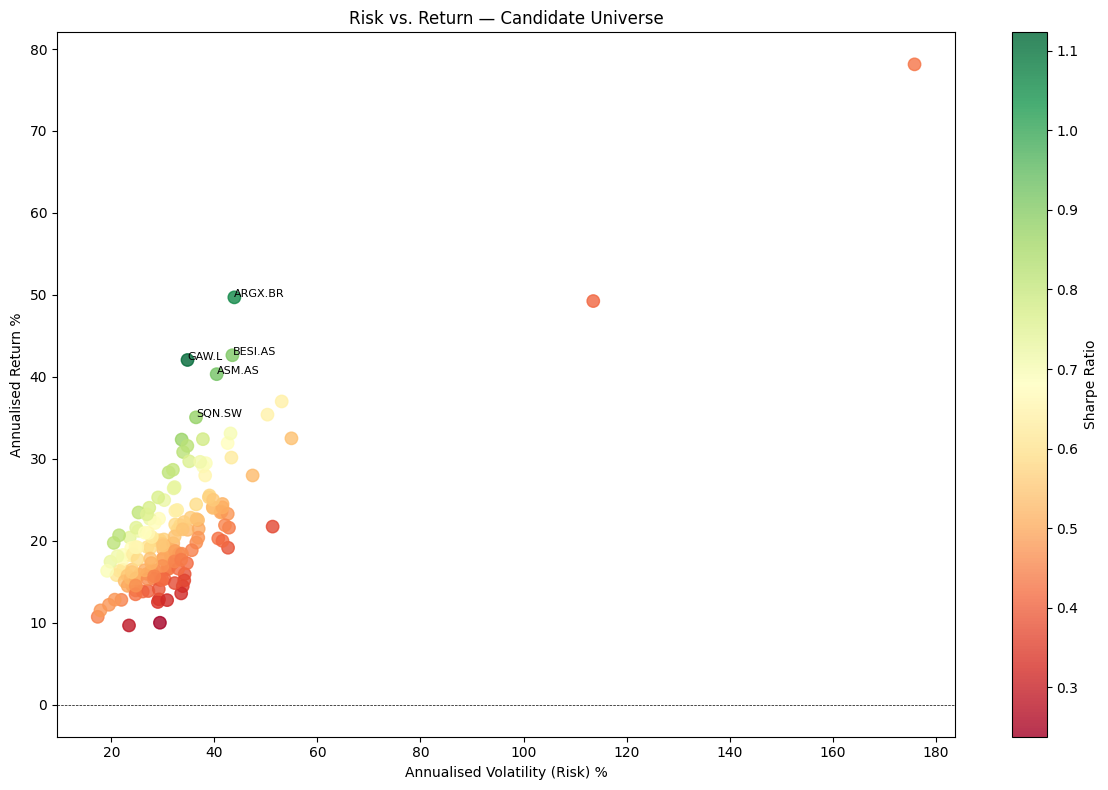

Chart saved.


In [9]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    financial_metrics["annual_volatility_pct"],
    financial_metrics["annual_return_pct"],
    c=financial_metrics["sharpe_ratio"],
    cmap="RdYlGn",
    s=80, alpha=0.8
)

plt.colorbar(scatter, label="Sharpe Ratio")
ax.set_xlabel("Annualised Volatility (Risk) %")
ax.set_ylabel("Annualised Return %")
ax.set_title("Risk vs. Return â€” Candidate Universe")
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")

# Label a few tickers
for _, row in financial_metrics.nlargest(5, "sharpe_ratio").iterrows():
    ax.annotate(row["ticker"], (row["annual_volatility_pct"], row["annual_return_pct"]),
                fontsize=8, ha="left")

plt.tight_layout()
plt.savefig("../outputs/reports/risk_return_chart.png", dpi=150)
plt.show()
print("Chart saved.")

## Step 9 â€” Save financial metrics

In [10]:
today = str(date.today())

# Full metrics (all stocks)
out_all = f"../outputs/scores/financial_metrics_{today}.csv"
financial_metrics.to_csv(out_all, index=False)

# Passed universe (survives vol + beta screens)
out_passed = f"../outputs/scores/financial_screen_passed_{today}.csv"
passed.to_csv(out_passed, index=False)

# Exclusion log
out_excl = f"../outputs/portfolio/financial_exclusions_{today}.csv"
excluded[["ticker", "annual_volatility_pct", "beta", "exclusion_reason"]].to_csv(out_excl, index=False)

print(f"Saved full metrics  : {out_all}")
print(f"Saved passed list   : {out_passed} ({len(passed)} stocks)")
print(f"Saved exclusion log : {out_excl} ({len(excluded)} stocks)")

Saved full metrics  : ../outputs/scores/financial_metrics_2026-05-12.csv
Saved passed list   : ../outputs/scores/financial_screen_passed_2026-05-12.csv (141 stocks)
Saved exclusion log : ../outputs/portfolio/financial_exclusions_2026-05-12.csv (23 stocks)


## Notebook complete

You now have:
- **Annual return and volatility** for every stock
- **Sharpe ratio** (return per unit of risk)
- **Maximum drawdown** (worst historical loss)
- **Return on Equity (ROE)** â€” profitability quality screen
- **Debt-to-Equity** â€” leverage quality screen
- **Revenue Growth** â€” top-line quality screen
- **Beta** vs STOXX Europe 600 â€” market sensitivity
- **Volatility cap filter** (>40% excluded)
- **Beta cap filter** (>1.5 excluded)
- A **risk-return scatter chart** ready for the presentation

Output files:
- `outputs/scores/financial_metrics_DATE.csv` â€” full metrics for all stocks
- `outputs/scores/financial_screen_passed_DATE.csv` â€” stocks that passed all financial screens
- `outputs/portfolio/financial_exclusions_DATE.csv` â€” excluded stocks with reason

**Next:** Open `agent05_06_esg_climate.ipynb` to build the ESG scores.